In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
import logging

from pcntoolkit import (
    BLR,
    BsplineBasisFunction,
    LinearBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(True)

In [2]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/BLR/Final_BLRs/Final_BLR_corrected_results"
model = NormativeModel.load(path)

In [7]:
full_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data/Full_Dataset_UKB_ADNI_OASIS3.csv")
full_data["rh_S_cingul-Marginalis_thickness"].describe()

count    36593.000000
mean         2.464943
std          0.215100
min          1.033000
25%          2.348000
50%          2.498000
75%          2.615000
max          3.776000
Name: rh_S_cingul-Marginalis_thickness, dtype: float64

In [3]:
full_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data/Full_Dataset_UKB_ADNI_OASIS3.csv")
data_df = full_data.iloc[:,1:]
demographic_data = full_data.iloc[:,:5]


data_df = data_df[~data_df["Site"].isin([3.0,9.0, 10.0, 14.0, 16.0, 19.0, 20.0, 24.0, 27.0, 35.0, 51.0, 57.0, 68.0, 62.0, 67.0, 70.0, 114.0, 130.0, 133.0, 135.0, 136.0, 141.0, 153.0])]
data_df = data_df[data_df["Site"].isin([128, 129, 2, 3, 6, 137, 11, 12, 13, 401, 11025, 11026, 11027, 403, 402, 405, 404, 11028, 23, 18, 22, 32, 33, 36, 37, 41, 941, 72, 73, 82, 99, 100, 109, 116, 123])]
#removing these ages because they had unique site & age combinations which could not be split 
data_df = data_df[data_df["Age"] != 96.0]
data_df = data_df[data_df["Age"] != 91.0]
data_df = data_df[data_df["Age"] != 95.0]
data_df = data_df[data_df["Age"] != 97.0]

data = data_df
covariates = ["Age"]
batch_effects = ["Sex", "Site"]

data_df = data_df.drop(columns=['Age','Sex','Site','Dataset', "Diagnosis"])
columns = list(data_df.columns)

response_vars = columns

# create a NormData object
norm_data = NormData.from_dataframe(
    name="Final_BLR_corrected", dataframe=data, covariates=covariates, batch_effects=batch_effects, response_vars=response_vars
)
norm_data.coords
train, test = norm_data.train_test_split([0.8, 0.2], random_state=42)
predictions = model.predict(test)


Process: 2621524 - 2026-06-12 17:51:25 - Dataset "Final_BLR_corrected" created.
    - 36169 observations
    - 36169 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Sex (2)
	Site (34)
    
Process: 2621524 - 2026-06-12 17:51:25 - Making predictions on 103 response variables.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for 103 response variables.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for rh_S_interm_prim-Jensen_thickness.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for lh_G_pariet_inf-Angular_thickness.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for CC_Mid_Posterior.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for lh_S_collat_transv_ant_thickness.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for Right-Lateral-Ventricle.
Process: 2621524 - 2026-06-12 17:51:25 - Computing z-scores for rh_G_oc-temp_lat-fusifor_thickness.
Process: 2621524 - 2026-0

/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7234.
  res = hypotest_fun_out(*samples, **kwds)
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7234.
  res = hypotest_fun_out(*samples, **kwds)
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/pcntoolkit/dataio/norm_data.py:1051: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_results = old_results.merge(zdf, on="observations", how="outer", suffixes=("_old", ""))
/ho

Process: 2621524 - 2026-06-12 17:57:25 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 103 response variables
    - 2 batch effects:
    	Sex (1)
	Site (1)
    
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for 103 response variables.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for rh_S_interm_prim-Jensen_thickness.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for lh_G_pariet_inf-Angular_thickness.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for CC_Mid_Posterior.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for lh_S_collat_transv_ant_thickness.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for Right-Lateral-Ventricle.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for rh_G_oc-temp_lat-fusifor_thickness.
Process: 2621524 - 2026-06-12 17:57:25 - Computing centiles for CC_Posterior.
Process: 2621524 - 2026-06-12 17:57:25 - Computing 

In [5]:
predictions.data_vars
predictions_copy = predictions.copy()
predictions_copy

<xarray.NormData> Size: 62MB
Dimensions:            (observations: 7234, response_vars: 103, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 11)
Coordinates:
  * observations       (observations) int64 58kB 15163 6208 ... 27340 31105
  * response_vars      (response_vars) <U34 14kB 'lh_G_front_inf-Triangul_thi...
  * covariates         (covariates) <U3 12B 'Age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'Sex' 'Site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
Data variables:
    subject_ids        (observations) int64 58kB 15163 6208 ... 27340 31105
    Y                  (observations, response_vars) float64 6MB 3.038 ... 1....
    X                  (observations, covariates) float64 58kB 54.0 ... 66.0
    batch_effects      (observations, batch_effect_dims) <U32 2MB '1.0' ... '...
    Z                  (observations, response_vars) float64 6MB 1.024 ... -0...
    centiles           (centile, observations, response_vars) float64 30MB 2....
    logp               (observations, response_vars) float64 6MB -1.328 ... -...
    Yhat               (observations, response_vars) float64 6MB 2.85 ... 3.4...
    statistics         (response_vars, statistic) float64 9kB 0.249 ... 0.7625
    Y_harmonized       (observations, response_vars) float64 6MB 3.054 ... 1....
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           Final_BLR_corrected_test
    unique_batch_effects:           {np.str_('Sex'): [np.str_('0.0'), np.str_...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('Age'): {'mean': np.float64(56.4...
    batch_effect_covariate_ranges:  {np.str_('Sex'): {np.str_('0.0'): {np.str...

In [35]:
import numpy as np
import xarray as xr
from scipy.stats import norm


def evaluate_msll(data):
    """
    Calculate Mean Standardized Log Loss (MSLL).

    Parameters
    ----------
    data : dataset-like object
        Must contain:
        - data["logp"]
        - data["baseline_logp"]

    Returns
    -------
    float
        MSLL value.
    """

    logp = data["logp"].values
    mll_model = -np.mean(logp)
    baseline_logp = data["baseline_logp"].values
    mll_baseline = -np.mean(baseline_logp)
    msll = mll_model - mll_baseline
    return float(msll)


def evaluate_msll_per_response(data):
    results = {}
    for responsevar in data.response_vars.values:
        subset = data.sel(response_vars=responsevar)
        logp = subset["logp"].values
        baseline_logp = subset["baseline_logp"].values
        mll_model = -np.mean(logp)
        mll_baseline = -np.mean(baseline_logp)
        results[str(responsevar)] = float(
            mll_model - mll_baseline
        )
    return results

def compute_baseline_logp(data):
    baseline_logp = xr.zeros_like(data["Y"])
    for responsevar in data.response_vars.values:
        y = (data["Y"].sel(response_vars=responsevar).values.squeeze())
        mu = np.mean(y)
        sigma = np.std(y, ddof=0)
        sigma = max(sigma, 1e-12)
        logp = norm.logpdf(y, loc=mu, scale=sigma)
        baseline_logp.loc[{"response_vars": responsevar}] = logp
    data["baseline_logp"] = baseline_logp
    return data

predictions = compute_baseline_logp(predictions)
msll = evaluate_msll_per_response(predictions)

pd.DataFrame(msll)

{'lh_G_front_inf-Triangul_thickness': 1.4027507319057426,
 'lh_G_front_middle_thickness': 1.4714430290278884,
 'lh_G_front_sup_thickness': 1.3653071366035954,
 'lh_G_oc-temp_lat-fusifor_thickness': 1.4106281014448354,
 'lh_G_oc-temp_med-Lingual_thickness': 1.7767027766707384,
 'lh_G_oc-temp_med-Parahip_thickness': 1.2753545004908429,
 'lh_G_occipital_middle_thickness': 1.679734380999352,
 'lh_G_orbital_thickness': 1.5817338946856179,
 'lh_G_pariet_inf-Angular_thickness': 1.4881005255098099,
 'lh_G_pariet_inf-Supramar_thickness': 1.4338017980200424,
 'lh_G_parietal_sup_thickness': 1.5201076213517555,
 'lh_G_postcentral_thickness': 1.4709339743365561,
 'lh_G_precentral_thickness': 1.2104808949709536,
 'lh_G_rectus_thickness': 1.3051022752696855,
 'lh_G_temp_sup-Lateral_thickness': 1.3480083117528603,
 'lh_G_temp_sup-Plan_tempo_thickness': 1.254415427694306,
 'lh_G_temporal_inf_thickness': 1.4879193033706237,
 'lh_G_temporal_middle_thickness': 1.51580231671279,
 'lh_Pole_occipital_thickne

<Axes: ylabel='Frequency'>

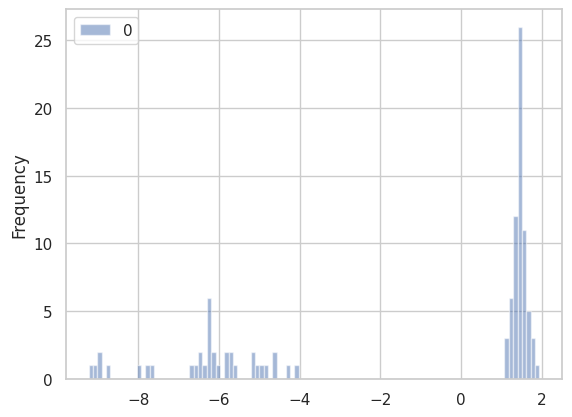

In [62]:
df = pd.DataFrame.from_dict(msll, orient='index')

f_df = df.iloc[:, :1]
f_df.reset_index()
plt.title("msll")
f_df.plot.hist(alpha=0.5, bins=103)



In [22]:
predictions_copy = predictions
predictions

<xarray.NormData> Size: 62MB
Dimensions:            (observations: 7234, response_vars: 103, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 11)
Coordinates:
  * observations       (observations) int64 58kB 15163 6208 ... 27340 31105
  * response_vars      (response_vars) <U34 14kB 'lh_G_front_inf-Triangul_thi...
  * covariates         (covariates) <U3 12B 'Age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'Sex' 'Site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
Data variables:
    subject_ids        (observations) int64 58kB 15163 6208 ... 27340 31105
    Y                  (observations, response_vars) float64 6MB 3.038 ... 1....
    X                  (observations, covariates) float64 58kB 54.0 ... 66.0
    batch_effects      (observations, batch_effect_dims) <U32 2MB '1.0' ... '...
    Z                  (observations, response_vars) float64 6MB 1.024 ... -0...
    centiles           (centile, observations, response_vars) float64 30MB 2....
    logp               (observations, response_vars) float64 6MB -1.328 ... -...
    Yhat               (observations, response_vars) float64 6MB 2.85 ... 3.4...
    statistics         (response_vars, statistic) float64 9kB 0.249 ... 0.7625
    Y_harmonized       (observations, response_vars) float64 6MB 3.054 ... 1....
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           Final_BLR_corrected_test
    unique_batch_effects:           {np.str_('Sex'): [np.str_('0.0'), np.str_...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('Age'): {'mean': np.float64(56.4...
    batch_effect_covariate_ranges:  {np.str_('Sex'): {np.str_('0.0'): {np.str...

In [64]:
z_scores = predictions["Z"]
z_scores


<xarray.DataArray 'Z' (observations: 36179, response_vars: 103)> Size: 30MB
array([[ 0.16147466,  1.32040717, -0.05673541, ..., -1.22646812,
        -0.37007724, -0.04781801],
       [ 1.25825145,  1.31394257,  0.7366488 , ...,  1.3191169 ,
        -0.08854631,  0.00857038],
       [-1.22703052, -0.74552479, -0.267326  , ..., -0.9587112 ,
         1.52622889, -0.60388153],
       ...,
       [-0.54413285, -0.25637321,  0.13715461, ...,  0.00237145,
         0.3758151 , -0.57832872],
       [-0.32642513, -0.55709207, -0.47904034, ...,  2.05014092,
        -1.12392161, -0.22052827],
       [-0.39741128, -0.4924192 , -0.11662871, ...,  1.45958562,
        -0.41583778, -0.32310644]], shape=(36179, 103))
Coordinates:
  * observations   (observations) int64 289kB 0 1 2 3 ... 36176 36177 36178
  * response_vars  (response_vars) <U34 14kB 'lh_G_front_inf-Triangul_thickne...

In [65]:
z_scores_df = z_scores.to_pandas()
z_scores_df

response_vars,lh_G_front_inf-Triangul_thickness,lh_G_front_middle_thickness,lh_G_front_sup_thickness,lh_G_oc-temp_lat-fusifor_thickness,lh_G_oc-temp_med-Lingual_thickness,lh_G_oc-temp_med-Parahip_thickness,lh_G_occipital_middle_thickness,lh_G_orbital_thickness,lh_G_pariet_inf-Angular_thickness,lh_G_pariet_inf-Supramar_thickness,...,Right-Cerebellum-White-Matter,Right-Hippocampus,Right-Inf-Lat-Vent,Right-Lateral-Ventricle,Right-Pallidum,Right-Putamen,Right-VentralDC,Right-choroid-plexus,Right-vessel,WM-hypointensities
observations,,,,,,,,,,,,,,,,,,,,,
0,0.161475,1.320407,-0.056735,1.294357,1.384397,-1.003119,1.355188,0.843418,0.552857,2.040968,...,-0.116918,-0.707538,-0.562996,-0.955802,-0.793076,-0.337703,-0.897019,-1.226468,-0.370077,-0.047818
1,1.258251,1.313943,0.736649,0.747934,-0.131506,-0.125343,-0.233921,1.914569,0.666651,-0.419647,...,0.146824,0.936833,-0.174064,0.135864,0.809520,1.568371,2.048215,1.319117,-0.088546,0.008570
2,-1.227031,-0.745525,-0.267326,-0.329517,-2.110965,-0.902251,-1.218075,-0.538536,-0.419839,-1.128544,...,-0.807809,-0.086696,-0.841184,0.167106,-0.698713,-0.662351,-0.101098,-0.958711,1.526229,-0.603882
3,-1.688684,-1.857091,-0.776091,-0.784740,-1.880629,-1.178239,-0.626924,-0.820454,-1.125904,-0.243315,...,0.178187,0.218929,1.690600,-0.655178,-0.421873,-0.006846,-0.924521,-0.903975,0.868838,-0.413928
4,0.311245,0.291094,0.413980,-0.145812,1.069822,1.256879,0.390881,-0.021285,0.227961,0.246042,...,-0.359672,0.225077,-0.051891,0.153420,-0.431378,0.630325,-0.093044,0.258699,1.737688,-0.548365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36174,-0.590425,0.730324,0.252165,1.863663,-0.116915,-0.687009,1.325708,-0.161916,0.464510,0.073668,...,-1.144986,-0.949676,0.979131,0.281654,-0.010405,0.942862,-0.892759,-0.164337,1.369702,0.541439
36175,0.848775,0.614721,0.577492,-0.502660,0.323909,-0.370906,-0.494490,0.053916,-0.025695,0.287772,...,-1.066549,-1.217413,2.687712,2.963627,0.044649,0.343873,0.005612,1.637536,1.198883,0.261302
36176,-0.544133,-0.256373,0.137155,-0.500095,-0.209240,-1.286080,-0.763235,-0.229195,-0.760333,-0.169069,...,-0.074704,-1.888012,0.771491,-0.430432,-0.151627,0.070558,-0.277890,0.002371,0.375815,-0.578329


In [69]:
z_scored_data = pd.concat([demographic_data, z_scores_df], axis=1)
z_scored_data

,Unnamed: 0,Age,Sex,Site,Diagnosis,lh_G_front_inf-Triangul_thickness,lh_G_front_middle_thickness,lh_G_front_sup_thickness,lh_G_oc-temp_lat-fusifor_thickness,lh_G_oc-temp_med-Lingual_thickness,...,Right-Cerebellum-White-Matter,Right-Hippocampus,Right-Inf-Lat-Vent,Right-Lateral-Ventricle,Right-Pallidum,Right-Putamen,Right-VentralDC,Right-choroid-plexus,Right-vessel,WM-hypointensities
0,0,60.0,0.0,11025.0,0.0,0.161475,1.320407,-0.056735,1.294357,1.384397,...,-0.116918,-0.707538,-0.562996,-0.955802,-0.793076,-0.337703,-0.897019,-1.226468,-0.370077,-0.047818
1,1,60.0,0.0,11025.0,0.0,1.258251,1.313943,0.736649,0.747934,-0.131506,...,0.146824,0.936833,-0.174064,0.135864,0.809520,1.568371,2.048215,1.319117,-0.088546,0.008570
2,2,62.0,0.0,11025.0,0.0,-1.227031,-0.745525,-0.267326,-0.329517,-2.110965,...,-0.807809,-0.086696,-0.841184,0.167106,-0.698713,-0.662351,-0.101098,-0.958711,1.526229,-0.603882
3,3,47.0,0.0,11025.0,0.0,-1.688684,-1.857091,-0.776091,-0.784740,-1.880629,...,0.178187,0.218929,1.690600,-0.655178,-0.421873,-0.006846,-0.924521,-0.903975,0.868838,-0.413928
4,4,45.0,0.0,11025.0,0.0,0.311245,0.291094,0.413980,-0.145812,1.069822,...,-0.359672,0.225077,-0.051891,0.153420,-0.431378,0.630325,-0.093044,0.258699,1.737688,-0.548365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36588,1888,72.0,1.0,403.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36589,1889,65.0,0.0,401.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36590,1890,71.0,0.0,401.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36591,1891,72.0,0.0,401.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
# demographic_data = demographic_data[~demographic_data["Site"].isin([9.0, 10.0, 14.0, 16.0, 19.0, 20.0, 24.0, 27.0, 35.0, 51.0, 57.0, 68.0, 62.0, 67.0, 70.0, 114.0, 130.0, 133.0, 135.0, 136.0, 141.0, 153.0])]
# demographic_data = demographic_data[demographic_data["Site"].isin([128, 129, 2, 3, 6, 137, 11, 12, 13, 401, 11025, 11026, 11027, 403, 402, 405, 404, 11028, 23, 18, 22, 32, 33, 36, 37, 41, 941, 72, 73, 82, 99, 100, 109, 116, 123])]
# #removing these ages because they had unique site & age combinations which could not be split 
# demographic_data = demographic_data[demographic_data["Age"] != 96.0]
# demographic_data = demographic_data[demographic_data["Age"] != 91.0]
# demographic_data = demographic_data[demographic_data["Age"] != 95.0]
# demographic_data = demographic_data[demographic_data["Age"] != 97.0]

# demographic_data.shape #(36593, 5)
# #z_scores_df.shape # (36179, 103)
# z_scored_data = pd.concat([demographic_data, z_scores_df], axis=1)
# z_scored_data

z_scores = predictions["Z"]
age = predictions["X"]
batch_effects = predictions["batch_effects"]

z_scores_df = z_scores.to_pandas()
age_df = age.to_pandas()
batch_effects_df = batch_effects.to_pandas()

z_scored_data = pd.merge([age_df, batch_effects_df, z_scores_df], on="observations", how="left")
z_scored_data

TypeError: merge() missing 1 required positional argument: 'right'

In [91]:
df = predictions.to_dataframe()
df

X             Y                                                  \
        Age 3rd-Ventricle 4th-Ventricle Brain-Stem CC_Anterior CC_Central   
0      60.0        1042.8        1818.5    19411.7       843.2      440.4   
1      60.0        3248.4        2777.2    22865.0       739.7      407.3   
2      62.0        1459.8        1194.8    19145.9      1050.7      478.7   
3      47.0         968.3        1442.7    21161.8       910.5      718.3   
4      45.0         860.3        1447.2    21304.0       882.6      559.7   
...     ...           ...           ...        ...         ...        ...   
36174  72.0        1552.9        2696.6    20124.8       752.7      366.6   
36175  65.0        3273.6        3007.1    18279.0       951.5      379.6   
36176  71.0        1245.6        2124.2    18019.3       707.0      350.8   
36177  72.0        2450.0        1317.7    18504.3       757.5      302.3   
36178  76.0        2725.4        1625.3    18537.1       687.2      324.8   

                                                             ...  \
      CC_Mid_Anterior CC_Mid_Posterior CC_Posterior     CSF  ...   
0               454.1            588.9        942.0   849.3  ...   
1               397.8            432.5        869.5   965.3  ...   
2               450.6            574.6       1099.9  1013.6  ...   
3               660.4            652.7       1142.6   821.1  ...   
4               624.6            612.5        923.9   932.2  ...   
...               ...              ...          ...     ...  ...   
36174           406.2            350.2        909.4  1133.0  ...   
36175           340.6            335.7       1016.9  1391.1  ...   
36176           348.2            293.1        904.0  1158.1  ...   
36177           306.4            256.1        969.6  1310.8  ...   
36178           293.0            248.5        924.8  1463.0  ...   

                                   centiles                            \
      (Right-Cerebellum-White-Matter, 0.95) (Right-Hippocampus, 0.95)   
0                              16801.142296               4587.756131   
1                              16801.142296               4587.756131   
2                              16642.880499               4535.627081   
3                              17739.296162               4805.429787   
4                              17815.548094               4817.186158   
...                                     ...                       ...   
36174                          18228.897455               4637.810984   
36175                          17099.389673               4558.132213   
36176                          16732.204404               4376.080718   
36177                          16682.211226               4347.601741   
36178                          16637.415609               4250.275469   

                                                                  \
      (Right-Inf-Lat-Vent, 0.95) (Right-Lateral-Ventricle, 0.95)   
0                     750.641811                    20553.736084   
1                     750.641811                    20553.736084   
2                     814.221104                    22072.080757   
3                     543.650490                    14964.422530   
4                     530.337359                    14480.867101   
...                          ...                             ...   
36174                1312.331304                    32097.532837   
36175                 706.683009                    18436.290904   
36176                 959.911552                    23290.198762   
36177                1017.244852                    24338.765410   
36178                1344.502252                    30076.438485   

                                                                            \
      (Right-Pallidum, 0.95) (Right-Putamen, 0.95) (Right-VentralDC, 0.95)   
0                2182.406001           5153.325569             4185.707154   
1                2182.406001           5153.325569    

In [119]:
df_age = df["X"]
df_age

df_z = df["Z"]
df_z

df_batch = df["batch_effects"]
df_batch

df_data = pd.concat([df_age, df_batch, df_z],axis=1)
df_data.shape
df_data

,Age,Sex,Site,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,CC_Mid_Anterior,CC_Mid_Posterior,...,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness
0,60.0,0.0,11025.0,-0.759699,0.198446,-0.621985,-0.460375,-0.622943,-0.470964,0.775268,...,0.475314,-1.714414,1.201952,0.883295,0.703961,-0.508776,-0.796756,-0.169875,-0.362247,0.147767
1,60.0,0.0,11025.0,3.100749,1.973852,1.098467,-1.102466,-0.960246,-0.991330,-0.960945,...,-1.202542,-1.264887,1.196953,-0.585566,-0.871409,0.987054,-1.720045,0.645995,0.460088,-0.285761
2,62.0,0.0,11025.0,0.245789,-1.123377,-0.663458,1.146783,-0.097032,-0.399700,0.698151,...,-0.287576,-1.377416,-1.168811,0.927110,0.299737,-1.082927,0.359352,-0.858029,-0.361281,-0.145961
3,47.0,0.0,11025.0,-0.169177,-0.521507,-0.044162,-0.256075,1.391697,0.865900,0.975841,...,-0.726719,-0.404064,0.740683,1.500053,-0.573735,-1.147554,-0.207261,-1.377837,0.043127,-0.160890
4,45.0,0.0,11025.0,-0.415007,-0.512727,0.019505,-0.488509,0.114691,0.525621,0.559084,...,0.139756,-0.786497,1.411154,0.922176,0.111752,-0.672006,0.960023,0.727125,0.863204,0.421188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36174,72.0,1.0,403.0,-0.239469,1.166096,-0.719190,-0.371487,-0.131120,0.212662,-0.094012,...,0.594757,0.366177,0.598613,-0.329786,-0.354043,-0.338974,-0.234597,-0.026151,0.939029,0.081973
36175,65.0,0.0,401.0,3.452148,2.173795,-0.589793,1.127374,-0.218895,-0.476108,-0.341466,...,0.265630,-0.124497,-0.601792,0.188298,-0.173214,1.179557,0.873204,-0.102372,0.584643,0.091110
36176,71.0,0.0,401.0,-0.077044,0.802080,-0.528566,-0.349847,-0.266685,-0.209841,-0.387008,...,0.079917,-0.699589,-0.611482,-1.111323,0.102336,-0.044907,-0.539506,0.036931,-0.317263,-0.384470
36177,72.0,0.0,401.0,2.014535,-0.840849,-0.343485,-0.033007,-0.622663,-0.492732,-0.557168,...,0.336407,-0.820209,-0.526622,-0.352428,-0.294445,-0.598325,1.020182,0.636621,0.142242,-0.389746


In [139]:
# check_df = pd.concat([df_age, df_batch, demographic_data],axis=1)
# check_df
full_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data/Full_Dataset_UKB_ADNI_OASIS3.csv")
data_df = full_data.iloc[:,1:]
demographic_data = full_data.iloc[:,:5]
demographic_data = demographic_data[~demographic_data["Site"].isin([9.0, 10.0, 14.0, 16.0, 19.0, 20.0, 24.0, 27.0, 35.0, 51.0, 57.0, 68.0, 62.0, 67.0, 70.0, 114.0, 130.0, 133.0, 135.0, 136.0, 141.0, 153.0])]
demographic_data = demographic_data[demographic_data["Site"].isin([128, 129, 2, 3, 6, 137, 11, 12, 13, 401, 11025, 11026, 11027, 403, 402, 405, 404, 11028, 23, 18, 22, 32, 33, 36, 37, 41, 941, 72, 73, 82, 99, 100, 109, 116, 123])]
#removing these ages because they had unique site & age combinations which could not be split 
demographic_data = demographic_data[demographic_data["Age"] != 96.0]
demographic_data = demographic_data[demographic_data["Age"] != 91.0]
demographic_data = demographic_data[demographic_data["Age"] != 95.0]
demographic_data = demographic_data[demographic_data["Age"] != 97.0]

demographic_data = demographic_data.iloc[:,1:]
demographic_data

,Age,Sex,Site,Diagnosis
0,60.0,0.0,11025.0,0.0
1,60.0,0.0,11025.0,0.0
2,62.0,0.0,11025.0,0.0
3,47.0,0.0,11025.0,0.0
4,45.0,0.0,11025.0,0.0
...,...,...,...,...
36588,72.0,1.0,403.0,0.0
36589,65.0,0.0,401.0,0.0
36590,71.0,0.0,401.0,1.0
36591,72.0,0.0,401.0,0.0


In [147]:
df_age = df["X"].reset_index(drop=True)
df_z = df["Z"].reset_index(drop=True)
df_batch = df["batch_effects"].reset_index(drop=True)
df_data = pd.concat([df_age, df_batch], axis=1)
df_diag = demographic_data["Diagnosis"].reset_index(drop=True)
df_diag_data = pd.concat([df_data, df_diag, df_z], axis=1)

In [148]:
df_diag_data

,Age,Sex,Site,Diagnosis,3rd-Ventricle,4th-Ventricle,Brain-Stem,CC_Anterior,CC_Central,CC_Mid_Anterior,...,rh_S_front_sup_thickness,rh_S_interm_prim-Jensen_thickness,rh_S_oc-temp_lat_thickness,rh_S_occipital_ant_thickness,rh_S_parieto_occipital_thickness,rh_S_pericallosal_thickness,rh_S_postcentral_thickness,rh_S_precentral-inf-part_thickness,rh_S_precentral-sup-part_thickness,rh_S_temporal_sup_thickness
0,60.0,0.0,11025.0,0.0,-0.759699,0.198446,-0.621985,-0.460375,-0.622943,-0.470964,...,0.475314,-1.714414,1.201952,0.883295,0.703961,-0.508776,-0.796756,-0.169875,-0.362247,0.147767
1,60.0,0.0,11025.0,0.0,3.100749,1.973852,1.098467,-1.102466,-0.960246,-0.991330,...,-1.202542,-1.264887,1.196953,-0.585566,-0.871409,0.987054,-1.720045,0.645995,0.460088,-0.285761
2,62.0,0.0,11025.0,0.0,0.245789,-1.123377,-0.663458,1.146783,-0.097032,-0.399700,...,-0.287576,-1.377416,-1.168811,0.927110,0.299737,-1.082927,0.359352,-0.858029,-0.361281,-0.145961
3,47.0,0.0,11025.0,0.0,-0.169177,-0.521507,-0.044162,-0.256075,1.391697,0.865900,...,-0.726719,-0.404064,0.740683,1.500053,-0.573735,-1.147554,-0.207261,-1.377837,0.043127,-0.160890
4,45.0,0.0,11025.0,0.0,-0.415007,-0.512727,0.019505,-0.488509,0.114691,0.525621,...,0.139756,-0.786497,1.411154,0.922176,0.111752,-0.672006,0.960023,0.727125,0.863204,0.421188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36174,72.0,1.0,403.0,0.0,-0.239469,1.166096,-0.719190,-0.371487,-0.131120,0.212662,...,0.594757,0.366177,0.598613,-0.329786,-0.354043,-0.338974,-0.234597,-0.026151,0.939029,0.081973
36175,65.0,0.0,401.0,0.0,3.452148,2.173795,-0.589793,1.127374,-0.218895,-0.476108,...,0.265630,-0.124497,-0.601792,0.188298,-0.173214,1.179557,0.873204,-0.102372,0.584643,0.091110
36176,71.0,0.0,401.0,1.0,-0.077044,0.802080,-0.528566,-0.349847,-0.266685,-0.209841,...,0.079917,-0.699589,-0.611482,-1.111323,0.102336,-0.044907,-0.539506,0.036931,-0.317263,-0.384470
36177,72.0,0.0,401.0,0.0,2.014535,-0.840849,-0.343485,-0.033007,-0.622663,-0.492732,...,0.336407,-0.820209,-0.526622,-0.352428,-0.294445,-0.598325,1.020182,0.636621,0.142242,-0.389746
